# 01 — Prikupljanje podataka i Fama-French faktorske izloženosti

Podatkovni temelj projekta s kliznim prozorom (point-in-time S&P 500).

1. Izgradi univerzum kao **uniju svih ikad-članova point-in-time S&P 500**
   2000.–2025. (tablica članstva iz F0.5, rekonstrukcija fja05680/sp500).
2. Preuzmi dnevne prilagođene zaključne cijene u obnovljivu parquet predmemoriju
   po dionici (uz Stooq dopunu iz F0.6), preuzorkuj na kraj mjeseca i izračunaj
   mjesečne + viškove prinosa.
3. Dohvati Fama-French petfaktorsku mjesečnu datoteku.
4. Izmjeri pokrivenost univerzuma po prozoru (F0.7) — pristranost preživjelih
   postaje izmjerena veličina.
5. Za svaki klizni prozor treniranja (60 mjeseci, refit svakih 12) procijeni
   petfaktorske izloženosti.

In [1]:
%load_ext autoreload
%autoreload 2

import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if str(Path.cwd().parent) not in sys.path:
    sys.path.insert(0, str(Path.cwd().parent))

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")

from src.data import preprocess
from src.factors import estimate_betas_all_windows
from src.backtest import generate_rolling_windows
from src.utils import (
    FIGURES_DIR,
    PROCESSED_DATA_DIR,
    PROJECT_END,
    PROJECT_START,
    ensure_dirs,
    set_seed,
)

ensure_dirs()
set_seed()


## 1.1 Izgradi point-in-time S&P 500 uniju, preuzmi cijene, izgradi mjesečne prinose

In [2]:
preprocessed = preprocess(start=PROJECT_START, end=PROJECT_END)
monthly_returns = preprocessed["monthly_returns"]
excess_returns = preprocessed["excess_returns"]
factors = preprocessed["factors"]
metadata = preprocessed["metadata"]
membership = preprocessed["membership"]

print("Veličina univerzuma nakon pretprocesiranja:", monthly_returns.shape[1])
print("Pokrivenost datuma:", monthly_returns.index.min().date(), "→", monthly_returns.index.max().date())
print("Oblik faktora:", factors.shape)
print("Neuspjela preuzimanja:", len(preprocessed["failed_downloads"]))

2026-06-11 23:46:37,253 ERROR $AABA: possibly delisted; no timezone found


2026-06-11 23:46:37,362 ERROR 
1 Failed download:


2026-06-11 23:46:37,362 ERROR ['AABA']: possibly delisted; no timezone found


2026-06-11 23:46:37,707 ERROR $AAMRQ: possibly delisted; no price data found  (1d 1999-12-01 -> 2026-01-01)


2026-06-11 23:46:37,708 ERROR 
1 Failed download:


...

2026-06-11 23:49:52,915 ERROR 
1 Failed download:


2026-06-11 23:49:52,916 ERROR ['YNR']: possibly delisted; no price data found  (1d 1999-12-01 -> 2026-01-01)


2026-06-11 23:49:53,227 INFO Preuzeto 321/321 novih oznaka (321 neuspjelih dosad)


2026-06-11 23:49:53,674 WARNING 321 oznaka nije uspjelo preuzeti: AABA, AAMRQ, ABC, ABKFQ, ABMD, ACAS, ACKH, ACS, ADS, AFS.A, AGC, AGN, AKS, ALTR, ALXN, AMCC, ANDW, ANRZQ, ANSS, ANTM...


Veličina univerzuma nakon pretprocesiranja: 758
Pokrivenost datuma: 2000-01-31 → 2025-12-31
Oblik faktora: (312, 6)
Neuspjela preuzimanja: 321


Provjeri jednu dionicu i jedan niz faktora.


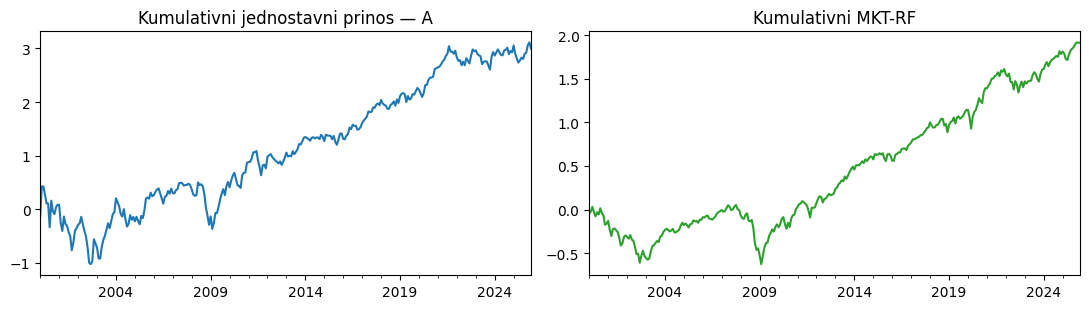

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
n_obs_per_ticker = monthly_returns.notna().sum(axis=0)
example_ticker = n_obs_per_ticker.idxmax()
monthly_returns[example_ticker].dropna().cumsum().plot(ax=axes[0], color="C0")
axes[0].set_title(f"Kumulativni jednostavni prinos — {example_ticker}")
axes[0].set_xlabel("")
factors["Mkt-RF"].cumsum().plot(ax=axes[1], color="C2")
axes[1].set_title("Kumulativni MKT-RF")
axes[1].set_xlabel("")
plt.tight_layout()
plt.show()


## 1.2 Klizni prozori i pokrivenost univerzuma po prozoru


In [4]:
windows = generate_rolling_windows(project_start=PROJECT_START, project_end=PROJECT_END)
print(f"{len(windows)} kliznih prozora generirano.")
for w in windows[:3]:
    print(w.label, w.train_start.date(), "→", w.train_end.date(),
          "| test", w.test_start.date(), "→", w.test_end.date())
print("...")
for w in windows[-2:]:
    print(w.label, w.train_start.date(), "→", w.train_end.date(),
          "| test", w.test_start.date(), "→", w.test_end.date())


21 kliznih prozora generirano.
2004-12 2000-01-31 → 2004-12-31 | test 2005-01-31 → 2005-12-31
2005-12 2001-01-31 → 2005-12-31 | test 2006-01-31 → 2006-12-31
2006-12 2002-01-31 → 2006-12-31 | test 2007-01-31 → 2007-12-31
...
2023-12 2019-01-31 → 2023-12-31 | test 2024-01-31 → 2024-12-31
2024-12 2020-01-31 → 2024-12-31 | test 2025-01-31 → 2025-12-31


2026-06-11 23:49:55,461 INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-11 23:49:55,461 INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


   train_window  n_eligible
0       2004-12         454
1       2005-12         466
2       2006-12         483
3       2007-12         491
4       2008-12         495
5       2009-12         511
6       2010-12         524
7       2011-12         537
8       2012-12         554
9       2013-12         564
10      2014-12         568
11      2015-12         579
12      2016-12         593
13      2017-12         606
14      2018-12         602
15      2019-12         606
16      2020-12         618
17      2021-12         624
18      2022-12         622
19      2023-12         627
20      2024-12         635


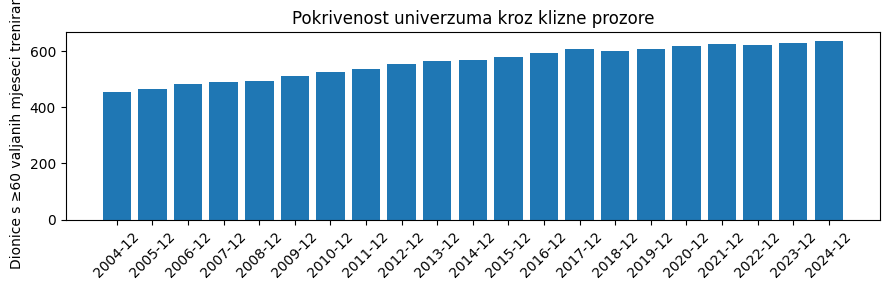

In [5]:
from src.utils import MIN_TRAINING_MONTHS

coverage_records = []
for window in windows:
    train_panel = monthly_returns.loc[window.train_start:window.train_end]
    eligible = (train_panel.notna().sum(axis=0) >= MIN_TRAINING_MONTHS).sum()
    coverage_records.append({"train_window": window.label, "n_eligible": int(eligible)})
coverage = pd.DataFrame(coverage_records)
print(coverage)

fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(coverage["train_window"], coverage["n_eligible"], color="C0")
ax.set_ylabel("Dionice s ≥60 valjanih mjeseci treniranja")
ax.set_title("Pokrivenost univerzuma kroz klizne prozore")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_universe_coverage.png", dpi=150)
plt.show()


## 1.2b Izvještaj pokrivenosti point-in-time članstva (F0.7)

Za svaki od 21 prozora: broj point-in-time članova na `train_end`, koliko ih
ima valjane cijene i koliko prolazi filtar ≥ 60 mjeseci treniranja. Po
zaključanoj odluci 1 — nepoznata pristranost preživjelih postaje izmjerena
veličina; rezultat se sprema u `outputs/tables/00_membership_coverage.csv`.

In [6]:
from src.data import membership_coverage_report
from src.utils import TABLES_DIR

coverage_membership = membership_coverage_report(
    monthly_returns,
    windows=windows,
    membership=membership,
    output_path=TABLES_DIR / "00_membership_coverage.csv",
)
print(coverage_membership.to_string(index=False))

train_window  n_members  n_with_prices  n_with_60m  pct_prices  pct_60m
     2004-12        495            284         271       57.37    54.75
     2005-12        497            295         285       59.36    57.34
     2006-12        497            302         293       60.76    58.95
     2007-12        497            321         309       64.59    62.17
     2008-12        498            328         308       65.86    61.85
     2009-12        499            339         322       67.94    64.53
     2010-12        497            345         333       69.42    67.00
     2011-12        497            353         345       71.03    69.42
     2012-12        497            362         349       72.84    70.22
     2013-12        497            367         352       73.84    70.82
     2014-12        499            373         358       74.75    71.74
     2015-12        502            392         369       78.09    73.51
     2016-12        506            411         390       81.23  

2026-06-11 23:49:55,632 INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-11 23:49:55,633 INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-11 23:49:55,634 INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-11 23:49:55,634 INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-11 23:49:55,635 INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-06-11 23:49:55,635 INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


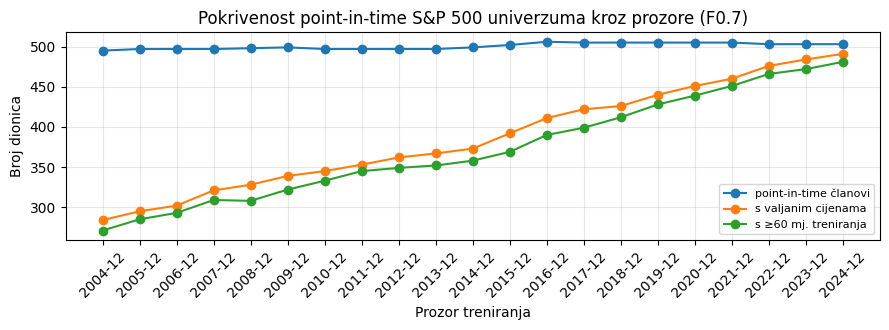

In [7]:
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(coverage_membership["train_window"], coverage_membership["n_members"],
        marker="o", label="point-in-time članovi")
ax.plot(coverage_membership["train_window"], coverage_membership["n_with_prices"],
        marker="o", label="s valjanim cijenama")
ax.plot(coverage_membership["train_window"], coverage_membership["n_with_60m"],
        marker="o", label="s ≥60 mj. treniranja")
ax.set_ylabel("Broj dionica")
ax.set_xlabel("Prozor treniranja")
ax.set_title("Pokrivenost point-in-time S&P 500 univerzuma kroz prozore (F0.7)")
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "00_membership_coverage.png", dpi=150)
plt.show()

## 1.3 Fama-French faktorske izloženosti po prozoru


In [8]:
factor_exposures = estimate_betas_all_windows(
    excess_returns=excess_returns,
    factors=factors,
    windows=[w.as_tuple() for w in windows],
)
factor_exposures_path = PROCESSED_DATA_DIR / "factor_exposures.csv"
factor_exposures.to_csv(factor_exposures_path, index=False)
print("Faktorske izloženosti:", factor_exposures.shape, "→", factor_exposures_path)
factor_exposures.head()


Faktorske izloženosti: (11481, 11) → /Users/marinmestrovic/Desktop/personal/daozip/data/processed/factor_exposures.csv


,train_window,ticker,alpha,beta_mkt,beta_smb,beta_hml,beta_rmw,beta_cma,residual_vol,r_squared,n_obs
0,2004-12,A,-0.012207,2.268467,0.766979,-1.169447,-0.133933,1.911981,0.134109,0.530283,60
1,2004-12,AAPL,0.030331,1.489466,0.896807,0.135008,0.194147,-1.956337,0.134575,0.427838,60
2,2004-12,ABT,0.011515,0.267597,-0.438208,-0.102240,0.002381,0.326597,0.071228,0.088925,60
3,2004-12,ACGL,0.012370,0.427543,0.452898,-0.315216,0.324092,0.364373,0.071028,0.097100,60
4,2004-12,ADBE,0.030113,1.042719,0.443200,-0.519355,-0.877012,0.372941,0.145838,0.377804,60


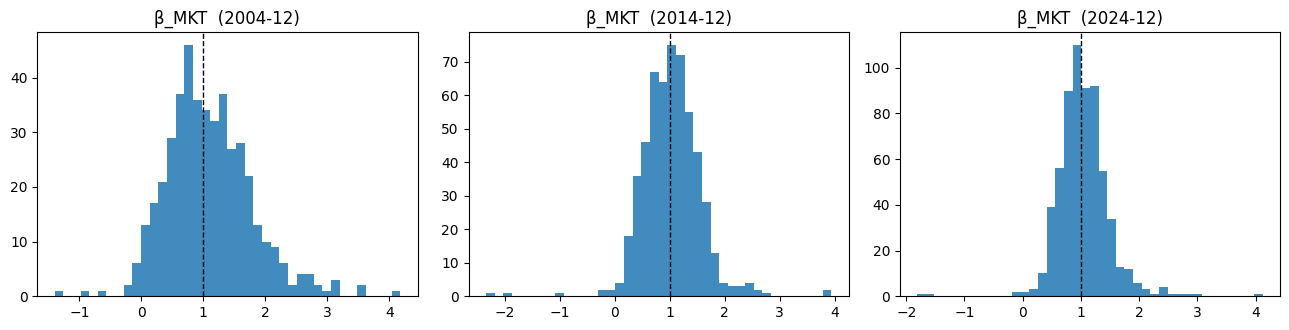

Medijan/IQR β_MKT po prozoru:
                median       std  count
train_window                           
2004-12       1.042135  0.688225    447
2005-12       0.990706  0.580629    457
2006-12       0.971893  0.623076    471
2007-12       0.995269  0.564648    478
2008-12       1.098557  0.586940    490
2009-12       1.061293  0.629859    498
2010-12       0.994363  0.545844    508
2011-12       1.007349  0.551374    521
2012-12       0.999210  0.572399    534
2013-12       0.984471  0.495244    540
2014-12       1.023833  0.532349    547
2015-12       1.009895  0.542578    560
2016-12       0.974728  0.508275    573
2017-12       0.992781  0.539635    584
2018-12       1.017116  0.467332    586
2019-12       1.011864  0.497516    592
2020-12       1.002473  0.518359    607
2021-12       0.974596  0.477088    616
2022-12       0.997735  0.452538    618
2023-12       1.019567  0.443426    624
2024-12       1.008390  0.446867    630


In [9]:
# Provjera razdiobi beta po prozoru.
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
sample_windows = [windows[0].label, windows[len(windows) // 2].label, windows[-1].label]
for ax, win in zip(axes, sample_windows):
    subset = factor_exposures.loc[factor_exposures["train_window"] == win, "beta_mkt"]
    ax.hist(subset, bins=40, color="C0", alpha=0.85)
    ax.axvline(1.0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"β_MKT  ({win})")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_beta_mkt_histograms.png", dpi=150)
plt.show()

print("Medijan/IQR β_MKT po prozoru:")
medians = factor_exposures.groupby("train_window")["beta_mkt"].agg(["median", "std", "count"])
print(medians)


β_MKT bi se trebao grupirati oko 1 (to je beta na tržišni faktor); SMB i HML
trebali bi obuhvaćati oba predznaka. Ako je razdioba nekog prozora degenerirana, univerzum
u tom prozoru je sumnjiv i treba ga ponovno provjeriti.
